## Study of activation functions

In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
x = np.linspace(-10, 10, 100)

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [5]:
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

In [6]:
tanh = np.tanh(x)

In [7]:
relu = np.maximum(0, x)

In [10]:
prametric_relu = relu + 0.01 * np.minimum(0,x)

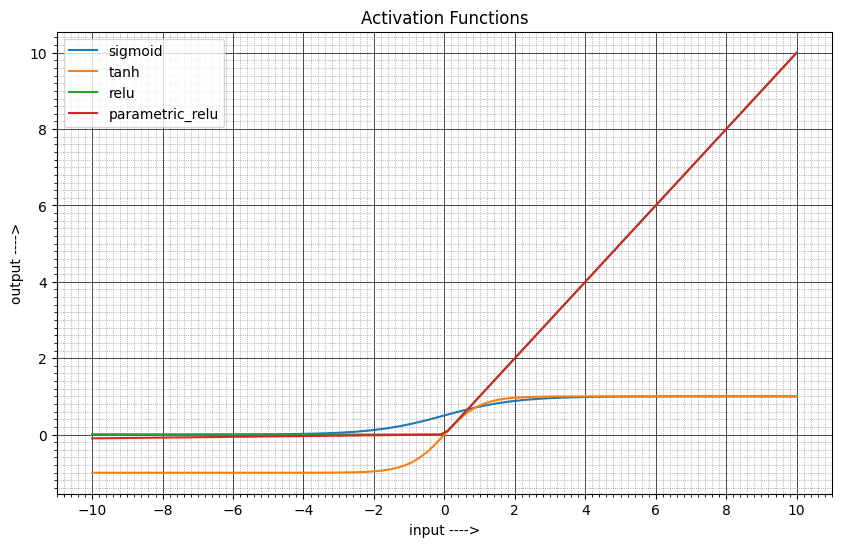

In [21]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x, sigmoid(x), label='sigmoid')
ax.plot(x, tanh, label='tanh')
ax.plot(x, relu, label='relu')
ax.plot(x, prametric_relu, label='parametric_relu')

# Configure major and minor ticks for detailed axis values
ax.xaxis.set_major_locator(ticker.MultipleLocator(2.0))   # Major x-ticks every 1 unit
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.2))   # Minor x-ticks every 0.2 units
ax.yaxis.set_major_locator(ticker.MultipleLocator(2.0))   # Major y-ticks every 1 unit
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.2))   # Minor y-ticks every 0.2 units

# Enable grids for both major and minor ticks
ax.grid(which='both')
ax.grid(which='major', linestyle='-', linewidth='0.5', color='black')
ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

ax.set_title('Activation Functions')
ax.set_xlabel('input ---->')
ax.set_ylabel('output ---->')
ax.legend()
plt.show()

## Customer churn prediction using an activation function

In [22]:
import pandas as pd

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.models import  Sequential
from tensorflow.keras.layers import  Dense


In [31]:
data = {
    "Age": [22, 35, 41, 29, 56, 48, 33, 62, 27, 45,
            38, 51, 24, 67, 31, 59, 43, 36, 28, 54],

    "MonthlyCharges": [45, 72, 89, 55, 120, 95, 63, 110, 50, 78,
                      68, 102, 40, 125, 59, 87, 73, 66, 52, 99],

    "Tenure": [2, 15, 24, 7, 36, 48, 12, 60, 5, 30,
               18, 42, 3, 72, 9, 54, 27, 21, 6, 39],
    "SupportCalls": [5,1,4,0,4,6,2,3,0,5,1,4,0,6,2,3,1,7,0.4,2],
    "Churn": [1, 0, 1, 0, 1, 0, 1,0, 1, 0, 1, 0, 1, 0,0,0,1,0,1,0]
}

In [32]:
df = pd.DataFrame(data)

In [33]:
X = df[['Age', 'MonthlyCharges', 'Tenure', 'SupportCalls']]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
model = Sequential()
model.add(Dense(8, activation='relu', input_shape = (4,)))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [37]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [47]:
model.fit(X_train_scaled, y_train, epochs=100, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7143 - loss: 0.5968
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7143 - loss: 0.5961
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7143 - loss: 0.5954
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7143 - loss: 0.5947
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7143 - loss: 0.5941
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7143 - loss: 0.5934
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7143 - loss: 0.5928
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7143 - loss: 0.5921
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7143 - loss: 0.5915
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7143 - loss: 0.5908
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7143 - loss: 0.5902
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.

In [50]:
model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([[0.32473502],
       [0.252085  ],
       [0.23625349],
       [0.65545714],
       [0.750267  ],
       [0.2700508 ]], dtype=float32)

In [51]:
accuracy_score(y_test, model.predict(X_test_scaled) > 0.5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


0.6666666666666666

In [46]:
probability = model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


### Evaluating the Neural Network's Performance
We will now run the predictions on our scaled test set, convert the output probabilities into binary class labels (0 or 1) using a standard threshold of `0.5`, and calculate the accuracy score against the actual labels (`y_test`).

In [52]:
# Get prediction probabilities for the test set
y_pred_prob = model.predict(X_test_scaled)

# Convert probabilities to binary class labels (True/False or 1/0)
y_pred = y_pred_prob > 0.5

# Calculate and print the accuracy score
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc * 100:.2f}%")

# Display detailed results alongside actual outcomes
results_df = pd.DataFrame({
    'Actual Churn': y_test.values,
    'Predicted Probability': y_pred_prob.flatten(),
    'Predicted Churn': y_pred.flatten().astype(int)
})
display(results_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Test Accuracy: 66.67%


,Actual Churn,Predicted Probability,Predicted Churn
0,1,0.324735,0
1,0,0.252085,0
2,0,0.236253,0
3,0,0.655457,1
4,1,0.750267,1
5,0,0.270051,0


In [53]:
confusion_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[3 1]
 [1 1]]


In [54]:
# Create a formatted DataFrame for the confusion matrix
cm_df = pd.DataFrame(
    confusion_matrix,
    index=['Actual: No Churn (0)', 'Actual: Churn (1)'],
    columns=['Predicted: No Churn (0)', 'Predicted: Churn (1)']
)

print("Confusion Matrix (Table Format):")
display(cm_df)

Confusion Matrix (Table Format):


,Predicted: No Churn (0),Predicted: Churn (1)
Actual: No Churn (0),3,1
Actual: Churn (1),1,1
